# Assignment 1 of Natural Language Processing
## Spam, Ham, and Phishing Email Classification using Machine Learning Techniques

Work assembled by Alejandro Gonçalves (202205564), Francisca Mihalache (202206022) and João Sousa (202205238).


## Table of Contents

1. [Introduction](#1-introduction)
2. [Dataset Description](#2-dataset-description)
   - 2.1. [Data Provenance](#21-data-provenance)
   - 2.2. [Data Structure](#21-data-structure)
   - 2.3. [Class Labels](#22-class-labels)
   - 2.4. [Dataset Size](#23-dataset-size)
   - 2.5. [Dataset Characteristics and Challenges](#24-dataset-characteristics-and-challenges)

3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis-eda)
   - 3.1. [Data Loading and Initial Inspection](#31-data-loading-and-initial-inspection)
   - 3.2. [Class Distribution Analysis](#32-class-distribution-analysis)
   - 3.3. [Text Length and Complexity Analysis](#33-text-length-and-complexity-analysis)
   - 3.4. [Linguistic Content Analysis (N-grams)](#34-linguistic-content-analysis-n-grams)
   - 3.5. [Special Character & Punctuation Density](#35-special-character--punctuation-density)
   - 3.6. [Vocabulary Richness (Lexical Diversity)]()

4. [Text Preprocessing](#4-text-preprocessing)
   - 4.1. [Data Loading and Initial Cleaning](#41-data-loading-and-initial-cleaning)
   - 4.2. [Lowercasing and Punctuation Removal](#42-lowercasing-and-punctuation-removal)
   - 4.3. [Tokenization and Stopword Removal](#43-tokenization-and-stopword-removal)
   - 4.4. [Lemmatization](#44-lemmatization)

5. [Feature Representation](#5-feature-representation)
   - 5.1. [TF-IDF (Term Frequency-Inverse Document Frequency)](#51-tf-idf-term-frequency-inverse-document-frequency)

6. [Baseline Model & Data Splitting](#6-baseline-model--data-splitting)
   - 6.1. [Train-Test Split](#61-train-test-split)
   - 6.2. [Why a Baseline Model?](#62-why-a-baseline-model)

7. [Classification Models](#7-classification-models)
   - 7.1. [Logistic Regression (Standard)](#71-logistic-regression-standard)
   - 7.2. [Random Forest (Standard)](#72-random-forest-standard)
   - 7.3. [Support Vector Machine (Standard)](#73-support-vector-machine-standard)
   - 7.4. [Comparison of Standard Models](#74-comparison-of-standard-models)

8. [Model Evaluation](#8-model-evaluation)
   - 8.1. [Evaluation Metrics](#81-evaluation-metrics)
   - 8.2. [Results Comparison](#82-results-comparison)

9. [Error Analysis](#9-error-analysis)

10. [Discussion](#10-discussion)

11. [Conclusion](#11-conclusion)

12. [References](#12-references)

### 1. Introduction
[[go back to the top]](#table-of-contents)

Text classification remains a fundamental task in Natural Language Processing (NLP), as it enables computers to automatically understand and organize large amounts of textual data. It plays a key role in security-related applications, such as detecting fraudulent messages, identifying phishing attempts, and filtering unwanted or harmful communications.

This project focuses on classifying emails into three categories: **Ham**, **Spam**, and **Phishing**. As phishing attacks become more sophisticated and increasingly resemble legitimate messages, it is essential to develop reliable traditional machine learning classifiers that can detect them efficiently. Such approaches are particularly valuable because they offer fast predictions and can be deployed in real-world systems where low latency and reliability are critical.

The objective of this assignment is to design, implement, and evaluate a complete NLP pipeline using a large-scale dataset of approximately 300,000 emails. Unlike traditional spam detection, which usually focuses on a simple binary distinction, this task is more challenging because it requires separating phishing emails from regular spam and legitimate messages. Phishing emails are often carefully crafted to appear trustworthy, making them harder to detect. To address this challenge, we explore different feature representation techniques, including sparse methods such as TF-IDF and dense representations based on word embeddings. These features are then used with traditional machine learning classifiers, including Naive Bayes, Support Vector Machines (SVM), and Gradient Boosting (XGBoost), allowing us to evaluate their effectiveness in accurately identifying each email category.

This report documents the entire development process, including:

- **Exploratory Data Analysis (EDA):** Identifying class imbalances and linguistic patterns.

- **Pre-processing & Feature Engineering:** Justifying the selection of lexicons and dimensionality reduction.

- **Model Evaluation:** A systematic comparison of classifiers using Precision, Recall, and Macro-F1 metrics.

- **Error Analysis:** A qualitative assessment of misclassified instances to identify model limitations.

By comparing different feature representations and machine learning models, this project aims to better understand how traditional ML techniques perform when applied to large-scale, real-world security datasets. This analysis helps highlight the strengths and limitations of each approach, providing insight into which combinations of features and classifiers are most effective for detecting spam and phishing in modern communication systems.


### 2. Dataset Description
[[go back to the top]](#table-of-contents)


#### 2.1. Data Provenance
[[go back to the topic]](#2-dataset-description)

The dataset is an ensemble of several historical and benchmark NLP collections, including the Enron Corpus (for legitimate communication), SpamAssassin, and specialized phishing repositories like the Nazario Phishing Archive. This diversity ensures that the model is exposed to various email formats, from professional corporate exchanges to modern fraudulent templates.

#### 2.2. Dataset Structure
[[go back to the topic]](#2-dataset-description)

The dataset consists of two main columns:

- **text**: contains the raw email content. This includes the body of the message and may contain informal language, formatting artifacts, or domain-specific vocabulary.
- **label**: contains the numerical class assigned to each email, representing its category.

Each row corresponds to a single email instance and its associated label.

#### 2.3. Class Labels
[[go back to the topic]](#2-dataset-description)

The classification task is a multi-class problem with three categories:

- **0 — Ham**: legitimate, non-malicious emails  
- **1 — Phishing**: malicious emails designed to deceive users and steal sensitive information  
- **2 — Spam**: unsolicited or irrelevant commercial or bulk emails  

This distinction is particularly important because phishing emails often closely resemble legitimate communication, making them more difficult to detect than traditional spam.


#### 2.4. Dataset Size
[[go back to the topic]](#2-dataset-description)

The dataset contains:

- **Total samples:** 365448 emails  
- **Number of classes:** 3  
- **Task type:** Multi-class text classification  
- **Language:** English  

The large size of the dataset makes it suitable for training and evaluating robust machine learning models and enables meaningful comparisons between different feature representations and classifiers.


#### 2.5. Dataset Characteristics and Challenges
[[go back to the topic]](#2-dataset-description)

This dataset presents several challenges typical of real-world NLP classification problems:

- High vocabulary diversity  
- Class overlap between phishing and legitimate emails (Phishing emails are designed to mimic Ham, making simple keyword detection insufficient.) 
- Informal and inconsistent text formatting  
- Potential class imbalance  
- Scalability (With over 365000 samples, creating a sparse feature matrix (like TF-IDF) requires careful memory management and feature selection (e.g., limiting max_features) to remain computationally feasible on a standard machine without using Deep Learning.)

These characteristics make the dataset a realistic benchmark for evaluating traditional machine learning approaches to email security and automated text classification.

### 3. Exploratory Data Analysis (EDA)
[[go back to the top]](#table-of-contents)

Before diving into preprocessing and model training, it is crucial to understand the underlying structure and characteristics of our dataset. Exploratory Data Analysis (EDA) allows us to identify patterns, detect potential anomalies (such as empty messages), and quantify the distribution of our target classes.

In this section, we focus on three main aspects:

- **Class Distribution:** To determine if the dataset is balanced or if certain categories (like Phishing) are underrepresented.

- **Message Length Analysis:** To see if the number of words or characters differs significantly between legitimate emails and malicious ones.

- **Data Integrity:** Identifying missing values or duplicates that could bias the model's performance.

Understanding these factors is essential for choosing the right evaluation metrics (e.g., Accuracy vs. Macro-F1) and for justifying our preprocessing decisions.

#### Imports

In [ ]:
import matplotlib.pyplot as plt
import string
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from tqdm import tqdm
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
import joblib

#### 3.1. Data Loading and Initial Inspection
[[go back to the topic]](#3-exploratory-data-analysis-eda)

In [ ]:
# Load the dataset
df = pd.read_csv('data/df.csv')

# 1. Dataset Dimensions
rows, cols = df.shape
print(f"Dataset Shape: {rows} rows and {cols} columns")

# 2. Alignment Check: Does every row have a label?
# We check if the number of labels matches the number of rows
total_labels = df['label'].count()
print(f"Total number of labels: {total_labels}")

if rows == total_labels:
    print("Verification Successful: Every row has an associated label.")
else:
    print(f"Warning: Integrity issue! {rows - total_labels} rows are missing a label.")

# 3. Text-Label Integrity (Missing values)
print("\nMissing values per column:")
missing = df.isnull().sum()
print(missing)

# 4. Basic Inspection of the first rows
print("\nFirst few rows of the dataset:")
print(df.head())

# 5. Numerical distribution of labels
print("\nNumerical distribution of labels:")
print(df['label'].value_counts())

Dataset Shape: 365448 rows and 2 columns
Total number of labels: 365448
Verification Successful: Every row has an associated label.

Missing values per column:
label    0
text     2
dtype: int64

First few rows of the dataset:
   label                                               text
0      0  wrong bill grace i ' ll forward original messa...
1      0  i have continued the hilcorp old ocean deal da...
2      0  several related issues have resulted in an inc...
3      0  one year rate for this one will be escapenumbe...
4      0  attached is the weekly deal report for escapen...

Numerical distribution of labels:
label
0    168455
2    154148
1     42845
Name: count, dtype: int64


In [ ]:
# Check a specific "multi-line" row to see how Pandas handles it
# Let's find a row that likely has many newlines
sample_multi_line = df[df['text'].str.contains('\n', na=False)].iloc[0]

print(f"Label: {sample_multi_line['label']}")
print("-" * 30)
print(f"Text content (as seen by Python):\n{sample_multi_line['text'][:500]}") 
# Python will show \n where the VS Code breaks the line

Label: 2
------------------------------
Text content (as seen by Python):
hello , welcome to pharmo attached nline sho longing p
- one of the leadi dehiscent ng oniine pharmaceutical shops
coruscation v
melinite g
a collaborator l
flaming ll
l prestige a
imparity rac homeless l
radiotrician is developer va
u anecdotic m
andmanyother .
- save over 50 medication %
- worldwide shl prosector pplng
- total co enclitic nfidentiaiity
- over 5 miiiion customers carefree in 130 countries
have a ni acclamation ce day !


In [ ]:
# Technical validation of the row vs. line discrepancy
logical_rows = len(df)
valid_labels = df['label'].count()

print(f"Logical Observations (Pandas): {logical_rows}")
print(f"Valid Labels found: {valid_labels}")

# Proof of multi-line content: Check if rows contain newline characters
multi_line_rows = df['text'].str.contains('\n').sum()
print(f"Rows containing internal line breaks: {multi_line_rows}")

if logical_rows == valid_labels:
    print("STATUS: Data integrity verified. Every logical row is correctly mapped to a label.")

Logical Observations (Pandas): 365448
Valid Labels found: 365448
Rows containing internal line breaks: 57812
STATUS: Data integrity verified. Every logical row is correctly mapped to a label.


During the initial inspection of the dataset, a discrepancy was observed between the number of physical lines displayed in a standard text editor (approximately 1.7 million) and the number of logical observations reported by the Pandas library (365448).

This difference is expected in raw email datasets and can be explained by how email content is stored and parsed.

**Embedded Newlines**

Many emails contain internal newline characters (`\n`) within the message body. These line breaks preserve the original structure and formatting of the email, such as:

- Professional signatures  
- Forwarded message threads  
- Bullet points or lists  
- Paragraph separation  

As a result, a single email can appear spread across multiple lines in a text editor, even though it still represents just one complete message.

---

**CSV Quoting Mechanism**

When stored in CSV format, email bodies containing line breaks are enclosed in double quotes (`"`). This ensures that the entire email content is treated as a single field. Data processing libraries such as Pandas correctly interpret all content within quotation marks as one logical observation, regardless of how many physical lines it occupies in the file.

Therefore, while the file appears to contain more lines at the physical level, the logical structure remains intact.

---

**Verification of Dataset Consistency**

To verify the integrity of the dataset after loading, the following checks were performed:

- `df.shape` confirmed the total number of observations
- `df["label"].count()` confirmed that each observation has a corresponding label

These checks verified that the dataset contains exactly **365448 valid samples**, each consisting of:

- One email text (`text`)
- One corresponding class label (`label`)

This confirms that no data was lost, truncated, or misaligned during the loading and parsing process.

#### 3.2. Class Distribution Analysis
[[go back to the topic]](#3-exploratory-data-analysis-eda)

Class Distribution Percentage:
Label 0: 46.10%
Label 2: 42.18%
Label 1: 11.72%


/tmp/ipykernel_7155/1915763620.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


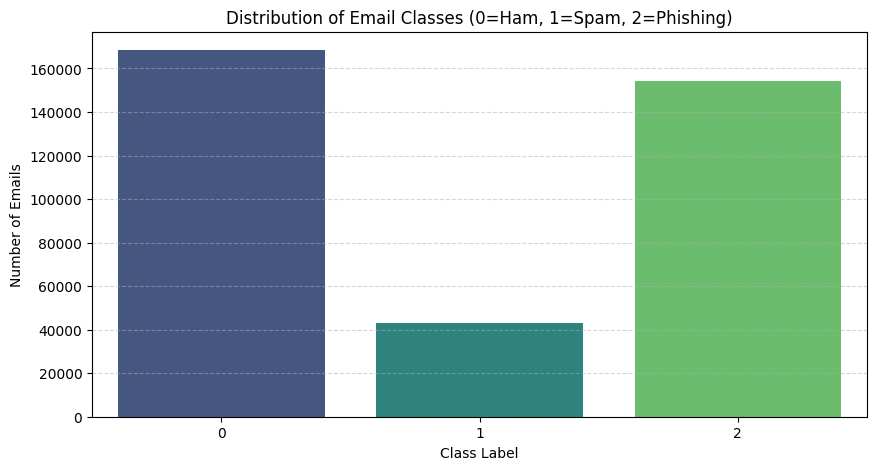

In [ ]:
# Calculate percentages for the report
class_pct = df['label'].value_counts(normalize=True) * 100

print("Class Distribution Percentage:")
for label, pct in class_pct.items():
    print(f"Label {label}: {pct:.2f}%")

# Visualization: Bar Plot
plt.figure(figsize=(10, 5))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of Email Classes (0=Ham, 1=Spam, 2=Phishing)')
plt.xlabel('Class Label')
plt.ylabel('Number of Emails')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

                W3GQThe visualization of the class distribution reveals the internal balance of our dataset across the three target categories.

Key observations from the distribution:

- **Dominant Classes:** Both `Ham` and `Phishing` represent the majority of the dataset, with Ham being the most frequent class (exceeding 160000 samples) and `Phishing` following closely (approximately 150000 samples).

- **Minority Class:** The `Spam` category is significantly underrepresented compared to the others, with roughly 40000 samples.

- **Implications for Modeling:** This distribution indicates a class imbalance. While the model will have ample examples to learn the patterns of legitimate emails and phishing attempts, it may struggle with the specific characteristics of generic spam. Consequently, relying solely on Accuracy might be misleading. We must prioritize **Macro-F1 Score** to ensure the classifier performs consistently across all categories, especially the minority one.

#### 3.3. Text Length and Complexity Analysis
[[go back to the topic]](#3-exploratory-data-analysis-eda)

In this section, we analyze the linguistic volume of the emails. Understanding the distribution of word counts helps identify if specific classes, such as phishing, tend to be more concise or if certain spam campaigns are unusually wordy. This analysis is also vital for detecting outliers, extreme cases that could negatively impact the training of our traditional machine learning models.

Word Count Statistics per Class:
             mean          std  min  median        max
label                                                 
0      346.262367  4302.027953  0.0   161.0  1585483.0
1      121.350239   594.751582  0.0    55.0   107710.0
2      209.373161   334.387849  0.0   110.0    25393.0


/tmp/ipykernel_7155/3115556438.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='word_count', data=df, palette='Set2')


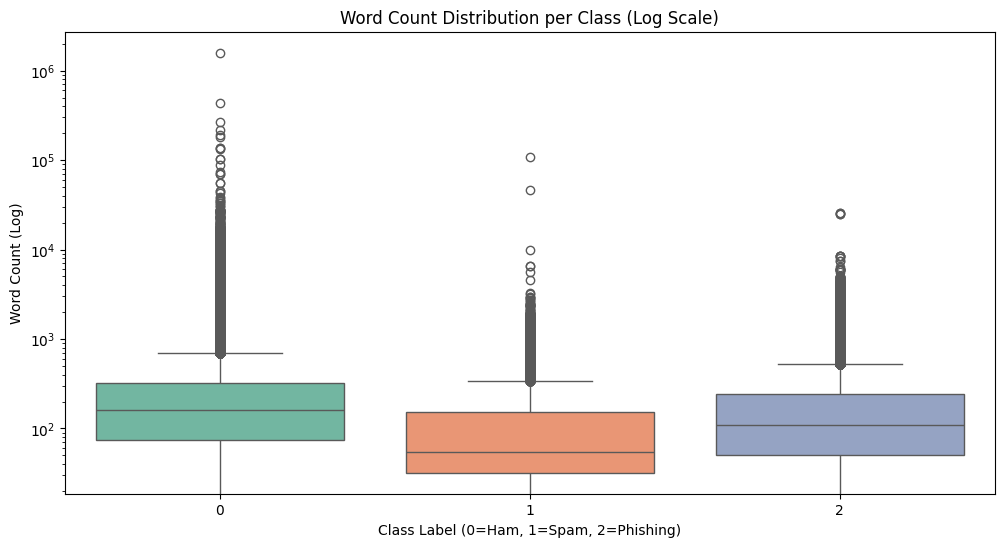

In [ ]:
# Force conversion to string and handle potential NaN values explicitly
# We use .fillna('') to ensure no float objects are processed
df['text'] = df['text'].fillna('').astype(str)

# Calculate word count for each email
# Now we are 100% sure 'x' is a string
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# Descriptive Statistics per Class
print("Word Count Statistics per Class:")
stats_report = df.groupby('label')['word_count'].describe()[['mean', 'std', 'min', '50%', 'max']]
stats_report = stats_report.rename(columns={'50%': 'median'})
print(stats_report)

# Visualization: Boxplot for Word Count (using Log Scale for readability)
plt.figure(figsize=(12, 6))
sns.boxplot(x='label', y='word_count', data=df, palette='Set2')
plt.yscale('log')
plt.title('Word Count Distribution per Class (Log Scale)')
plt.xlabel('Class Label (0=Ham, 1=Spam, 2=Phishing)')
plt.ylabel('Word Count (Log)')
plt.show()

The descriptive statistics reveal a significant "skewness" in the data, particularly in the Ham and Spam classes.

- **Ham (0) - Complexity and Massive Outliers:** This class exhibits the highest average (346 words) but a much lower median of 161 words. This gap indicates a right-skewed distribution, where most emails are around 160 words, but a few extreme outliers (reaching a maximum of 1585483 words) are pulling the mean upwards. Such extreme cases are likely system logs or corrupted files, not standard human communication.

- **Phishing (2) - Controlled Messaging:** Phishing attempts are more consistent, with a median of 110 words and a mean of 209. This suggests a deliberate strategy of being concise enough to induce quick action while maintaining enough professional "padding" to appear legitimate.

- **Spam (1) - Brief and Direct:** This is the most concise class, with a median of only 55 words. These messages typically rely on short promotional slogans or direct links rather than long-form text.

The presence of 2 missing values in the `text` column was handled by converting them into empty strings. Subsequent analysis showed that these, along with other pre-existing entries, resulted in a minimum word count of 0. These 'empty' observations are linguistically uninformative and will be removed in the preprocessing stage to prevent noise in the model training.

**The "Zero-Word" Issue:** All classes show a minimum value (`min`) of 0.0, indicating that some emails contain no usable textual content. These entries may correspond to empty messages or emails composed only of non-textual elements, such as images, attachments, or formatting artifacts. Since these observations contain no words, they do not provide any meaningful linguistic information for feature extraction or model training. Keeping them in the dataset could introduce noise and negatively affect model performance. Therefore, these entries must be identified and removed during the preprocessing stage.



#### 3.4. Linguistic Content Analysis (N-grams)
[[go back to the topic]](#3-exploratory-data-analysis-eda)

While word counts provide a structural overview, they do not reveal the semantic differences between classes. To understand the "vocabulary" of each category, we analyze the most frequent sequences of words (N-grams). This helps identify "trigger phrases" in Phishing (e.g., "account verification") versus professional jargon in Ham (e.g., "original message").

Starting N-gram extraction...


Processing Categories: 100%|██████████| 3/3 [02:59<00:00, 59.87s/it] 


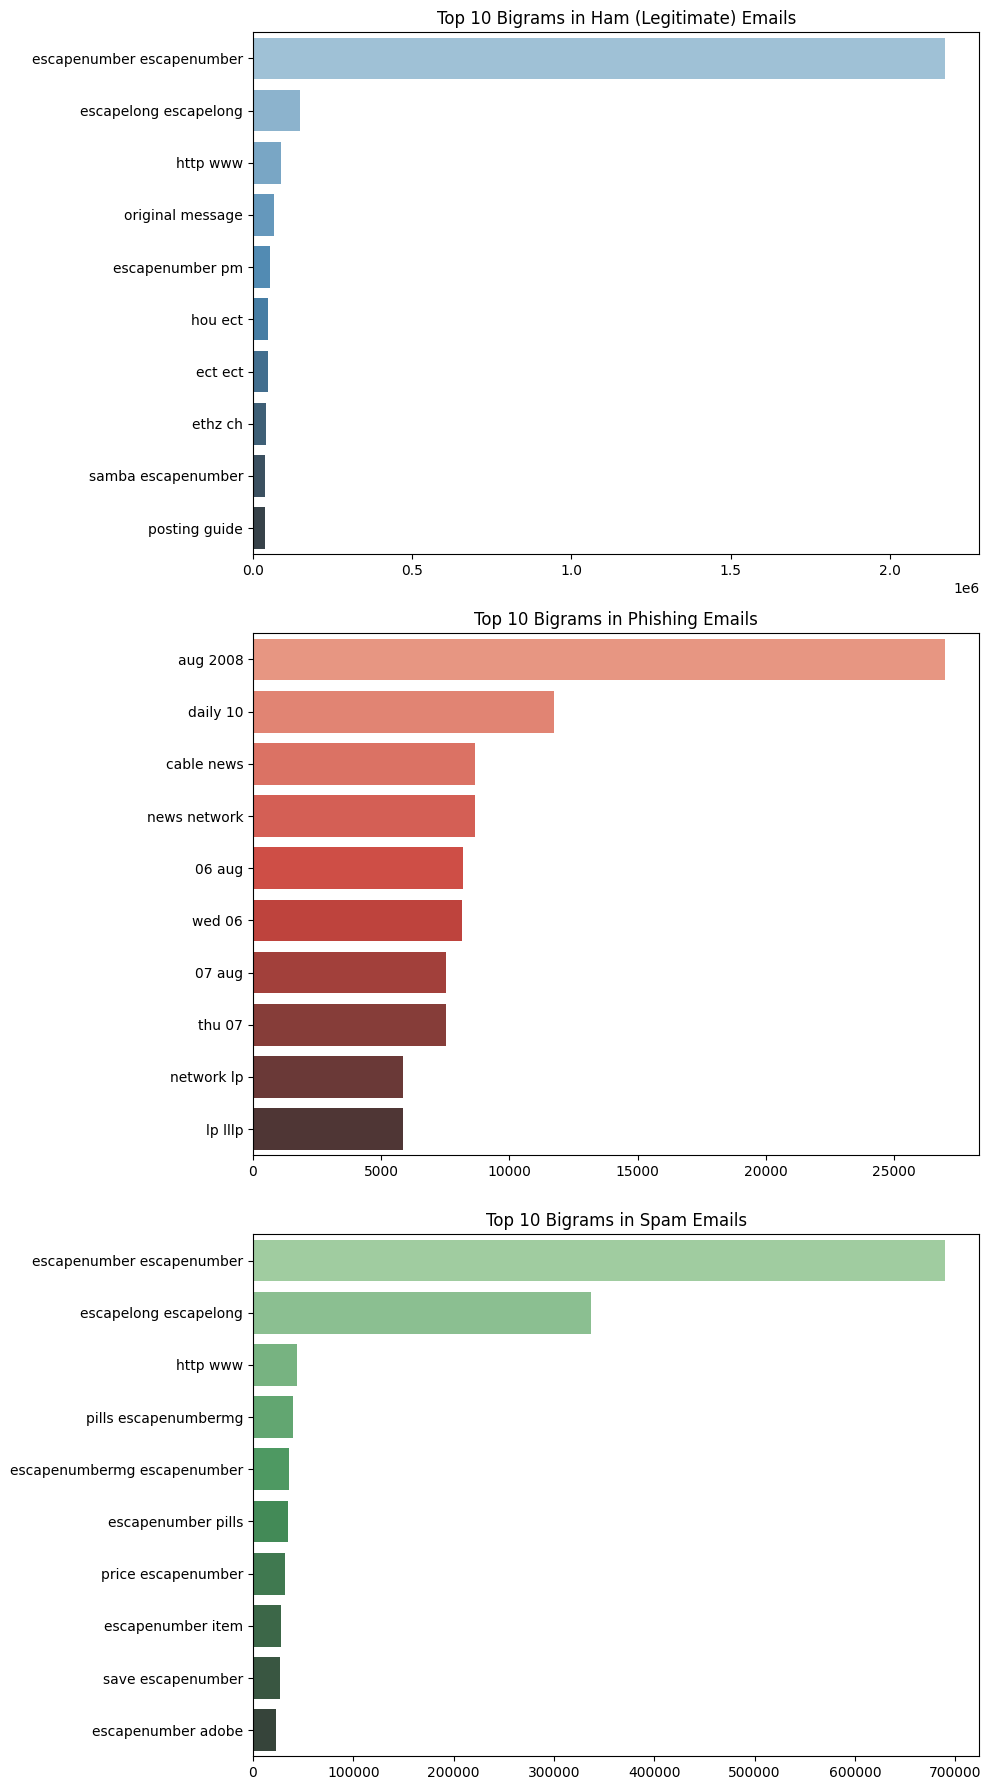

In [ ]:
def get_top_ngram(corpus, n=None, top_k=10):
    """
    Extracts the most frequent n-grams from a given corpus efficiently.
    """
    # Note: We filter English stop words to avoid common terms like 'of the', 'in a'
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english')
    # Use fit_transform instead of fit and transform separately for efficiency
    bag_of_words = vec.fit_transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Setup for the subplots
labels = [0, 1, 2]
# CORRECTED: titles and colors must match section 2.3 of the dataset description
titles = ['Ham (Legitimate)', 'Phishing', 'Spam']
colors = ['Blues_d', 'Reds_d', 'Greens_d']
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# Process each class with a progress bar
print("Starting N-gram extraction...")
for i, label in enumerate(tqdm(labels, desc="Processing Categories")):
    # Extracting top bigrams (n=2)
    corpus = df[df['label'] == label]['text']
    top_ngrams = get_top_ngram(corpus, n=2)
    
    # Prepare data for plotting
    x_val, y_val = map(list, zip(*top_ngrams))
    
    # Plotting - Added hue and legend=False to avoid Seaborn warnings
    sns.barplot(x=y_val, y=x_val, ax=axes[i], palette=colors[i], hue=x_val, legend=False)
    axes[i].set_title(f'Top 10 Bigrams in {titles[i]} Emails')

plt.tight_layout()
plt.show()

The linguistic patterns observed in our analysis reveal distinct characteristics for each class.

- **Ham (Legitimate) Emails:** The dominant phrases here reflect a professional and administrative context. We see significant occurrences of terms like `"original message"` and `"hou ect"` which point toward standard corporate forwarding and internal routing common in professional archives. The high frequency of masked tokens such as `"escapenumber escapenumber"` suggests that numerical data like dates and times were replaced during initial dataset preparation to preserve privacy.

- **Phishing Emails:** The most striking feature of the phishing category is a heavy reliance on temporal urgency and news-style formatting. Phrases like `"aug 2008"` and `"daily 10"` along with `"cable news"` or `"news network"` suggest these messages often mimic informational newsletters or urgent alerts to deceive recipients into taking immediate action. This class demonstrates a more specific vocabulary aimed at mimicking trustworthy informational sources.

- **Spam Emails:** Commercial bulk mail displays a repetitive focus on products and transactions. We see specific mentions of `"pills"` and software like `"adobe"` paired with commercial keywords such as `"price"` and `"save"` or `"item."` Like the Ham category, it features a massive amount of `"escapenumber"` and `"escapelong"` tokens which indicate that these emails originally contained many phone numbers, prices, and long promotional URLs that have been standardized for the NLP task.

#### 3.5. Special Character & Punctuation Density
[[go back to the topic]](#3-exploratory-data-analysis-eda)

Spam and phishing emails often rely on excessive punctuation (e.g., "!!!") or special symbols (e.g., "$", "%") to grab attention or indicate financial urgency. Analyzing the density of these characters can provide a strong non-textual feature for our traditional classifiers.

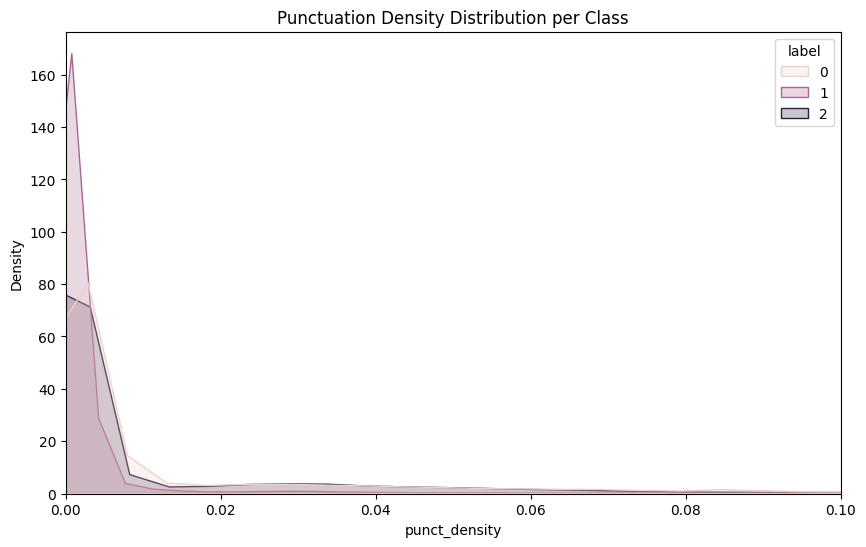

In [ ]:
# Calculate percentage of special characters
def count_special_chars(text):
    count = sum([1 for char in text if char in string.punctuation])
    return count / len(text) if len(text) > 0 else 0

df['punct_density'] = df['text'].apply(count_special_chars)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='punct_density', hue='label', common_norm=False, fill=True)
plt.title('Punctuation Density Distribution per Class')
plt.xlim(0, 0.1) # Zooming in on the most common range
plt.show()

**Distribution and Trends Across Classes** 
The density distribution reveals how each class typically formats its messages.

- **Ham (0) and Phishing (2):** These two classes show a similar, more spread-out distribution in punctuation density. For `Ham`, this represents the natural variety found in human communication, ranging from short informal notes to long technical reports with structured punctuation. `Phishing emails` often mirror this density because they are designed to look like legitimate Ham to bypass simple filters, frequently using standard professional signatures and corporate footers.

- **Spam (1):** This class displays the most significant spike at very low punctuation levels. This trend is likely due to the highly processed nature of the `Spam` samples in this dataset. As seen in the bigram analysis, many promotional links and pricing details were replaced by the `"escapelong"` and `"escapenumber"` tokens, effectively removing the original punctuation like periods, slashes, and currency symbols from the analyzed text.

- **Statistical Outliers:** Across all classes, there is a "long tail" of emails with punctuation density extending toward 0.10. While less frequent, these represent messages with high concentrations of special characters, often found in technical logs, data tables, or aggressive marketing subject lines designed to create visual urgency.

By understanding these punctuation patterns, we can see that while `Phishing` tries to hide by mimicking `Ham` formatting, `Spam` often has a distinct structural signature. This data supports the need for the next step in our analysis: examining the variety of words used in each message.

#### 3.6. Vocabulary Richness (Lexical Diversity)
[[go back to the topic]](#3-exploratory-data-analysis-eda)

Lexical diversity is the ratio of unique words to the total number of words. Legitimate corporate communication (Ham) often exhibits a richer, more varied vocabulary, whereas Spam and Phishing are frequently repetitive or use templated language.

/tmp/ipykernel_7155/695483333.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='lexical_richness', data=df, palette='Set3')


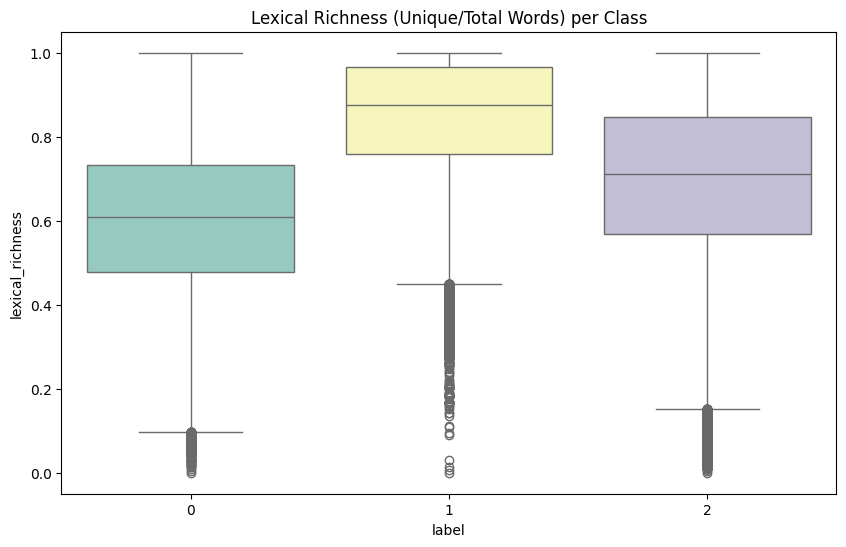

In [ ]:
def lexical_diversity(text):
    words = text.lower().split()
    if len(words) == 0: return 0
    return len(set(words)) / len(words)

df['lexical_richness'] = df['text'].apply(lexical_diversity)

plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='lexical_richness', data=df, palette='Set3')
plt.title('Lexical Richness (Unique/Total Words) per Class')
plt.show()

Lexical richness serves as a linguistic fingerprint for our three classes. High diversity suggests a broad, non-repetitive vocabulary often found in legitimate communication, while lower diversity frequently indicates templated or repetitive content typical of mass marketing or automated spam.

**Comparative Vocabulary Insights**
The distribution of lexical richness highlights clear differences in the communicative style of each class.

- **Spam (1):** Surprisingly, the Spam class demonstrates the highest median lexical richness, with most values concentrated between 0.8 and 1.0. This suggests that despite being bulk mail, the messages often contain a high variety of unique words relative to their length. This could be a result of "word salad" techniques used to bypass filters or simply very short messages where almost every word is unique.

- **Phishing (2):** This class occupies a middle ground, showing a wider interquartile range than the other categories. While the median richness is higher than that of legitimate mail, the broad distribution suggests that Phishing attempts range from highly repetitive, automated templates to more unique, hand-crafted messages designed to deceive specific targets.

- **Ham (0):** Legitimate emails show the lowest median lexical richness. This is characteristic of natural language in a corporate or personal setting, where common functional words (e.g., "the," "is," "and") and specific professional terms are frequently repeated throughout longer message bodies. The presence of numerous outliers at the lower end represents very long e-mails or attachments where a few terms are used extensively.

This analysis concludes our **Exploratory Data Analysis** phase. By combining insights from class distribution, word counts, bigrams, punctuation, and lexical richness, we have built a comprehensive profile of the dataset. This understanding will now guide our decisions in the [[Section 4]](#4-text-preprocessing): Text Preprocessing phase, where we will clean and normalize the data for our machine learning models.

### 4. Text Preprocessing
[[go back to the top]](#table-of-contents)

In this section we clean the dataset by removing empty entries and extreme outliers. We also normalize the text by converting everything to lowercase, removing unwanted punctuation, and stripping away common words that carry little semantic value.

#### 4.1. Data Loading and Initial Cleaning
[[go back to the topic]](#4-text-preprocessing)

In [ ]:
# Load the dataset
df = pd.read_csv('data/df.csv')

# 1. Check and Remove Duplicates first
# We do this before any other processing to ensure data integrity
initial_rows = len(df)
df = df.drop_duplicates(subset=['text'])
print(f"Removed {initial_rows - len(df)} duplicate rows.")

# 2. Handle missing values and convert text to string
# fillna('') ensures nulls become empty strings, and .astype(str) guarantees the data type
df['text'] = df['text'].fillna('').astype(str)

# 3. Calculate word count for filtering
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# 4. Filter empty entries and extreme outliers
# We exclude emails with 0 words and those exceeding 2000 words to avoid noise and memory issues
df = df[(df['word_count'] > 0) & (df['word_count'] <= 2000)]
print(f"Remaining samples after structural cleaning: {len(df)}")

Removed 84498 duplicate rows.
Remaining samples after structural cleaning: 278461


#### 4.2. Lowercasing and Punctuation Removal
[[go back to the topic]](#4-text-preprocessing)

In [ ]:
def normalize_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove special characters and punctuation
    # We keep only alphanumeric characters and spaces
    text = re.sub(r'[^\w\s]', '', text)
    # Standardize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply normalization with a progress bar
tqdm.pandas(desc="Normalizing Text")
df['normalized_text'] = df['text'].progress_apply(normalize_text)

Normalizing Text: 100%|██████████| 278461/278461 [00:27<00:00, 9992.01it/s] 


#### 4.3. Tokenization and Stopword Removal
[[go back to the topic]](#4-text-preprocessing)

Tokenization is the first step in text processing. It involves splitting a continuous piece of text into smaller units called tokens, which usually correspond to individual words. After tokenization, it is common to perform stopword removal. Stopwords are very frequent words such as “the”, “is”, “at”, and “on” that appear in almost all texts and typically do not help distinguish between different classes of emails.

Because these words carry very little discriminative power, removing them allows our models to focus on the **"keywords"** that actually define the intent of the message. For instance, in a phishing attack, words like `"bank,"` `"verify,"` or `"suspend"` are far more informative than the articles or prepositions surrounding them.

In [ ]:
# Download the official NLTK stopword list
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    # Split the text into individual tokens
    tokens = text.split()
    # Filter out tokens that are in the stopword list
    filtered_tokens = [word for word in tokens if word not in stop_words]
    # Reconstruct the string to maintain the modular pipeline structure
    return " ".join(filtered_tokens)

# Apply stopword removal with a progress bar for transparency
tqdm.pandas(desc="Removing Stopwords")
df['filtered_text'] = df['normalized_text'].progress_apply(remove_stopwords)

# Display a quick comparison to verify the effect
print("\nSample before stopword removal:")
print(df['normalized_text'].iloc[0][:100])
print("\nSample after stopword removal:")
print(df['filtered_text'].iloc[0][:100])

[nltk_data] Downloading package stopwords to /home/joao-
[nltk_data]     sousa/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
Removing Stopwords: 100%|██████████| 278461/278461 [00:08<00:00, 32157.68it/s]


Sample before stopword removal:
wrong bill grace i ll forward original message from rodriguez grace sent friday june escapenumber es

Sample after stopword removal:
wrong bill grace forward original message rodriguez grace sent friday june escapenumber escapenumber


#### 4.4. Lemmatization
[[go back to the topic]](#4-text-preprocessing)

Lemmatization is the process of grouping different inflected forms of a word so they can be treated as a single term, identified by its base or dictionary form, known as the lemma. Unlike stemming, which simply removes word endings, lemmatization takes context into account and converts a word into its meaningful root form. For example, the words `running`, `ran`, and `runs` are all reduced to `run`.

This step is important for our classification task because it helps unify the features in the dataset. By ensuring that `banking` and `bank` are treated as the same token, we reinforce the statistical patterns that models such as Naive Bayes or Logistic Regression rely on to detect phishing attempts.

In [ ]:
# Download the WordNet dictionary
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    # Split text into tokens
    tokens = text.split()
    # Lemmatize each word to its dictionary root
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(lemmatized_tokens)

# Apply lemmatization to the previously filtered text
print("Starting Lemmatization process...")
tqdm.pandas(desc="Lemmatizing")
df['final_text'] = df['filtered_text'].progress_apply(lemmatize_text)

# Final Quality Check: Remove any rows that may have become empty after preprocessing
initial_len = len(df)
df = df[df['final_text'].str.strip() != ""]
print(f"Removed {initial_len - len(df)} rows that became empty after lemmatization.")

print(f"Preprocessing complete. Final dataset size: {len(df)}")

[nltk_data] Downloading package wordnet to /home/joao-
[nltk_data]     sousa/nltk_data...
[nltk_data] Downloading package omw-1.4 to /home/joao-
[nltk_data]     sousa/nltk_data...


Starting Lemmatization process...


Lemmatizing: 100%|██████████| 278461/278461 [02:14<00:00, 2064.56it/s]


Removed 30 rows that became empty after lemmatization.
Preprocessing complete. Final dataset size: 278431


In [ ]:
# Save the current state of the DataFrame to a new CSV file
# index=False prevents pandas from adding an extra 'Unnamed: 0' column
df.to_csv('data/df_preprocessed.csv', index=False)

print(f"Checkpoint created: 'data/df_preprocessed.csv'")
print(f"Final row count at this stage: {len(df)}")

Checkpoint created: 'data/df_preprocessed.csv'
Final row count at this stage: 278431


### 5. Feature Representation
[[go back to the top]](#table-of-contents)

The goal of feature representation is to convert the lemmatized text into a **numerical format** that reflects the statistical importance of each word. Although **Bag of Words** is the simplest approach, we adopt **TF-IDF** as the main feature representation method because it provides a more informative and discriminative encoding for large scale email classification.

**Bag of Words** relies purely on raw frequency counts. If a word appears ten times in an email, its value in the vector is ten. This simplicity is attractive, but it introduces important limitations. Words that survive preprocessing and appear frequently across most emails such as subject, know, or message receive high weights simply because they are common. In a dataset with hundreds of thousands of emails, this leads to noisy matrices where **generic words dominate the representation** and weaken the signals that actually differentiate phishing from legitimate messages. Bag of Words has no notion of how informative a term is in relation to the entire corpus.

**TF-IDF** addresses this limitation by combining two complementary components:

- **Term Frequency (TF):** Measures how important a word is within a specific email by counting how often it appears in that message.

- **Inverse Document Frequency (IDF):** Reduces the weight of words that appear very frequently across the entire dataset, such as common business terms in the Enron corpus, and increases the weight of words that are rarer and more class specific, such as terms commonly associated with phishing or spam.

By combining these two factors, TF-IDF assigns higher importance to words that are both frequent in a particular message and uncommon in the overall corpus, making the representation more discriminative for classification tasks.


This distinction is crucial for phishing detection. In the Enron corpus, for example, the word `enron` appears very often in legitimate emails. TF-IDF significantly reduces its influence because it does not help separate classes. On the other hand, terms typically associated with phishing such as `verify`, `suspend`, or `account` are less common globally but highly indicative when they appear. TF-IDF assigns them higher weights, allowing the classifier to focus on truly discriminative features.

By emphasizing informative terms and downweighting generic ones, TF-IDF produces a cleaner and more semantically meaningful representation. This improves the effectiveness of traditional models such as `Naive Bayes` or `Support Vector Machines` when dealing with high dimensional data and large datasets, reducing the impact of noise and lowering the risk of overfitting on frequent but uninformative words.

In [ ]:
# Load the dataset
df = pd.read_csv('data/df_preprocessed.csv')

#### 5.1. TF-IDF (Term Frequency-Inverse Document Frequency)
[[go back to the topic]](#5-feature-representation)


In [ ]:
# 1. Initialize the Vectorizer
# We limit to 5000 features to maintain performance and memory efficiency
tfidf = TfidfVectorizer(max_features=5000)

# 2. Fit and transform the processed text
print("Converting text to TF-IDF features...")
X = tfidf.fit_transform(df['final_text'])

# 3. Get the target labels
y = df['label']

print(f"Feature matrix shape: {X.shape}") # Should be (n_samples, 5000)

Converting text to TF-IDF features...
Feature matrix shape: (278431, 5000)


##### Word distribution

/tmp/ipykernel_7155/2110202039.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tfidf_score', y='word', data=tfidf_df, palette='magma')


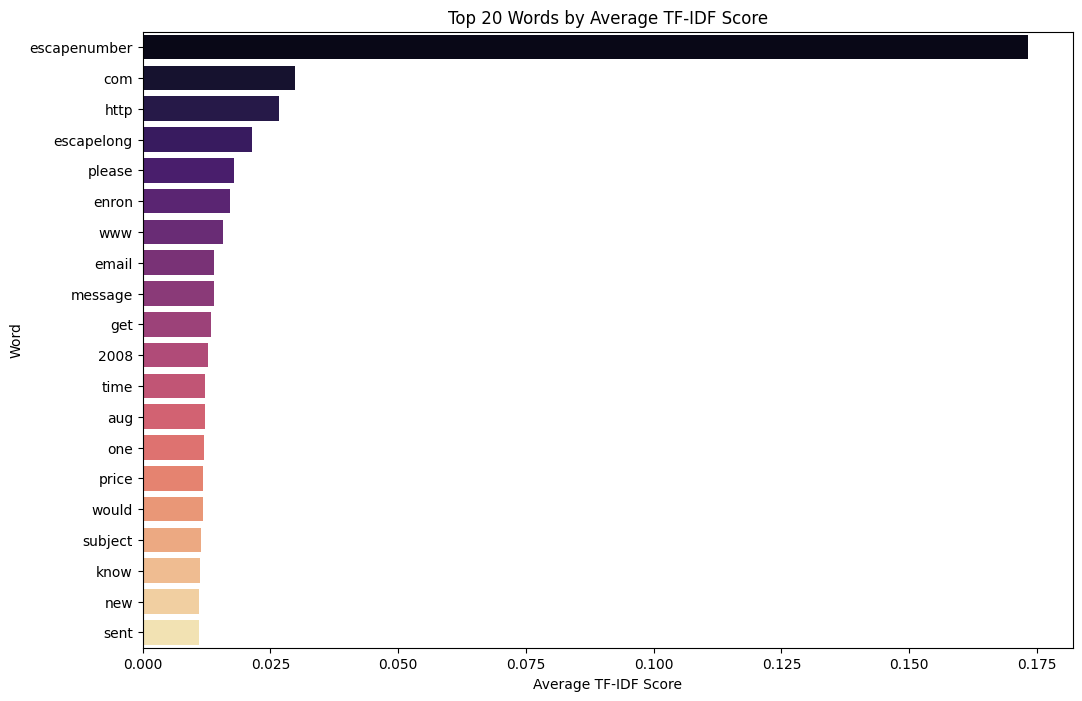

Total size of the feature space: 5000 features.


In [ ]:
# 1. Calculate the average TF-IDF score for each word across all documents
# X is your sparse matrix from tfidf.fit_transform
avg_tfidf = np.asarray(X.mean(axis=0)).ravel()
feature_names = np.array(tfidf.get_feature_names_out())

# 2. Create a DataFrame for easy sorting and plotting
tfidf_df = pd.DataFrame({'word': feature_names, 'tfidf_score': avg_tfidf})
tfidf_df = tfidf_df.sort_values(by='tfidf_score', ascending=False).head(20)

# 3. Visualization
plt.figure(figsize=(12, 8))
sns.barplot(x='tfidf_score', y='word', data=tfidf_df, palette='magma')
plt.title('Top 20 Words by Average TF-IDF Score')
plt.xlabel('Average TF-IDF Score')
plt.ylabel('Word')
plt.show()

print(f"Total size of the feature space: {len(feature_names)} features.")

The visualization of the top 20 terms ranked by their average TF-IDF score provides useful insight into both the characteristics of the dataset and the behaviour of the preprocessing pipeline.

A first observation concerns the strong presence of the tokens `escapenumber` and `escapelong`. These tokens are artifacts already present in the dataset when it was downloaded. During the dataset’s original preprocessing, certain patterns were replaced with placeholder tokens. For example, `escapenumber` represents numerical values such as dates, prices, or codes, while `escapelong` typically replaces long sequences of characters or repeated patterns. This means that these placeholders were not created during our own preprocessing pipeline but were inherited from the dataset itself.

The token `escapenumber` represents numerical values such as dates, prices, or codes, and its high importance suggests that the presence of numbers is a structural feature that appears frequently across many emails. Similarly, `escapelong` typically replaces long sequences of characters or repeated patterns that might correspond to identifiers, hashes, or noisy strings. Their prominence indicates that structural patterns remain informative signals within the corpus.

Several high-ranking terms are also related to digital communication and web infrastructure, including `com`, `http`, `www`, and `email`. The importance of these terms reflects the heavy presence of links and online references in the dataset. Although such tokens appear in many types of emails, their high TF-IDF values suggest that they are particularly characteristic of messages such as spam or phishing, where URLs and external references are central elements of the content.

Temporal indicators are also visible among the most relevant terms. Words such as `2008`, `aug`, and `time` point to a specific chronological context within the dataset, likely reflecting the time period during which the spam and phishing samples were collected.

Another group of frequent terms corresponds to standard email communication language. Words such as `please`, `get`, `would`, and `subject` appear among the top features even after stopword removal. Their persistence indicates that they occur extremely frequently and are retained because they are considered content words rather than classical stopwords in common lexicons such as NLTK.

Finally, the token `enron` stands out as a particularly discriminative feature. This reflects the origin of the legitimate email messages in the dataset, which are derived from the Enron email corpus. As a result, the presence of this term becomes a strong indicator of the Ham class.

Overall, the feature distribution suggests that the representation space is influenced not only by lexical content but also by structural characteristics of the emails, particularly the presence of numbers, placeholders, and web related tokens. This indicates that class separation in the dataset may depend as much on structural signals as on the specific vocabulary used in the messages.

### 6. Baseline Model & Data Splitting
[[go back to the top]](#table-of-contents)

Before training our classifiers, we must establish a robust evaluation framework. This begins by partitioning our 278431 samples into two distinct sets: a **Training Set** to build the models and a **Test Set** to act as unseen data for final performance validation.

#### 6.1. Train-Test Split
[[go back to the topic]](#6-baseline-model--data-splitting)

We will use an 80/20 split, which is standard for datasets of this magnitude. Furthermore, we apply stratify=y to ensure that the proportion of Ham, Spam, and Phishing remains identical in both sets, preventing any class imbalance issues during evaluation.

In [ ]:
# Splitting the data: 80% for training and 20% for testing
# random_state=42 ensures the results are reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (222744, 5000)
Test set shape: (55687, 5000)


#### 6.2. Why a Baseline Model?
[[go back to the topic]](#6-baseline-model--data-splitting)

A Baseline is the simplest possible model that gives us a starting point for performance. For text classification, the **Multinomial Naive Bayes** is the ideal candidate. It is extremely fast, works well with high-dimensional sparse matrices (like our TF-IDF), and provides a benchmark that more complex models (like SVM or Random Forest) must beat.

In [ ]:
# 1. Initialize and train the Baseline Model
nb_model = MultinomialNB()
print("Training Multinomial Naive Bayes (Baseline)...")
nb_model.fit(X_train, y_train)

# 2. Make predictions on the test set
y_pred = nb_model.predict(X_test)

# 3. Evaluate the results
print("\n--- Baseline Model Evaluation (Naive Bayes) ---")
print(classification_report(y_test, y_pred))

Training Multinomial Naive Bayes (Baseline)...

--- Baseline Model Evaluation (Naive Bayes) ---
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     25243
           1       0.93      0.66      0.77      8562
           2       0.84      0.90      0.87     21882

    accuracy                           0.89     55687
   macro avg       0.90      0.84      0.86     55687
weighted avg       0.89      0.89      0.89     55687



The implementation of the **Multinomial Naive Bayes** model served its role as an initial baseline, providing a reference point for evaluating more advanced approaches. While the overall accuracy of 89% appears encouraging at first glance, a closer inspection of the class level metrics reveals important limitations that guide the next steps of our modeling strategy.

**The Phishing Detection Problem**

The model achieved a recall of 0.66 for Class 1 (Phishing). In practical terms, this means that the system failed to detect about 34% of phishing attacks. In a cybersecurity context, this level of missed attacks is unacceptable because undetected phishing emails can lead directly to credential theft or system compromise.

**Limitations of the Independence Assumption**

Multinomial Naive Bayes assumes that words occur independently of each other. This assumption allows the model to remain computationally efficient, but it also limits its ability to capture more subtle linguistic patterns. Phishing messages often imitate legitimate communication, and detecting them requires understanding combinations of words and contextual cues that a simple probabilistic independence assumption cannot fully capture.

**Motivation for a Sequential Modeling Strategy**

Based on these observations, we defined a two step optimization strategy.

First, we transition to discriminative models in [[Section 7]](#7-classification-models). Before modifying the dataset itself, we test whether more expressive algorithms such as Logistic Regression can improve the separation between classes by learning explicit weights for each feature.

Second, we address the class imbalance problem using class weights. In the dataset, phishing emails represent only about 11% of all samples. By assigning higher penalties to mistakes on the minority class, the model is encouraged to focus more strongly on detecting phishing attacks without needing to generate synthetic data or discard existing observations.

This comparative strategy allows us to clearly measure how much of the final improvement comes from the choice of algorithm and how much results from correcting the statistical imbalance in the dataset.

### 7. Classification Models
[[go back to the top]](#table-of-contents)

In this section, we transition from probabilistic baseline models to discriminative classifiers. Unlike Naive Bayes, these models learn optimal weights for each feature to maximize the separation between classes, which is essential for detecting sophisticated phishing attempts that mimic legitimate communication.

#### 7.1. Logistic Regression (Standard)
[[go back to the topic]](#7-classification-models)

Logistic Regression is a robust linear classifier that predicts class probabilities using a logistic function. We first implement a "standard" version without adjusting for class imbalance to isolate the performance gain provided by the algorithm change alone.

In [ ]:
# 1. Initialize the model with standard settings
# 'multinomial' for multi-class tasks and 'lbfgs' for efficient optimization on large datasets
log_reg_std = LogisticRegression(solver='lbfgs', max_iter=1000)
# 2. Train the model using the training set
print("Training Standard Logistic Regression...")
log_reg_std.fit(X_train, y_train)

# 3. Predict on the unseen test set
y_pred_log_std = log_reg_std.predict(X_test)

# 4. Evaluate the performance
print("\n--- Logistic Regression (Standard) Evaluation ---")
print(classification_report(y_test, y_pred_log_std))

Training Standard Logistic Regression...

--- Logistic Regression (Standard) Evaluation ---
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     25243
           1       0.88      0.78      0.83      8562
           2       0.89      0.93      0.91     21882

    accuracy                           0.93     55687
   macro avg       0.92      0.90      0.90     55687
weighted avg       0.93      0.93      0.93     55687



Switching from the probabilistic Naive Bayes baseline to a discriminative model such as **Logistic Regression** led to a clear improvement in performance. The overall **accuracy increased** from 89% to 93%, and the **Macro F1-score reached 0.90**, indicating a better balance across classes.

The most important improvement appears in **phishing detection**. Recall for the phishing class **increased** from 0.66 to 0.78, showing that Logistic Regression is more effective at capturing the subtle feature patterns commonly used in phishing emails. At the same time, the model continues to perform extremely well on legitimate emails, achieving an **F1-score** of 0.97 for the Ham class and therefore producing very few false positives.

Despite these gains, the model still fails to detect about 22% of phishing attempts. This remaining gap is largely explained by the class imbalance observed during the exploratory analysis, where Ham and Spam messages significantly outnumber phishing samples and therefore continue to dominate the decision boundary.

#### 7.2. Random Forest (Standard)
[[go back to the topic]](#7-classification-models)

Now that we understand the importance of structural tokens, we move to Random Forest. This model is an ensemble of decision trees that can capture non-linear relationships between these features (e.g., the combination of "http" and "escapenumber" appearing together) .


In [ ]:
# 1. Initialize Random Forest
# n_jobs=-1 uses all available CPU cores
rf_std = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train the model
print("Training Standard Random Forest...")
rf_std.fit(X_train, y_train)

# 3. Predict and Evaluate
y_pred_rf_std = rf_std.predict(X_test)

print("\n--- Random Forest (Standard) Evaluation ---")
print(classification_report(y_test, y_pred_rf_std))

Training Standard Random Forest...

--- Random Forest (Standard) Evaluation ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     25243
           1       0.83      0.74      0.79      8562
           2       0.89      0.92      0.91     21882

    accuracy                           0.92     55687
   macro avg       0.90      0.89      0.89     55687
weighted avg       0.92      0.92      0.92     55687



The **Random Forest classifier** achieved an overall accuracy of 92% and performed extremely well in identifying legitimate emails, reaching an **F1-score** of 0.99 for the Ham class. However, when looking more closely at the minority class, the results reveal some important limitations.

For phishing detection, the model reached a **recall** of 0.74. This represents an improvement compared to the Naive Bayes baseline, which achieved a recall of 0.66, but it still **performs worse** than the **standard Logistic Regression** model, which reached 0.78. This behaviour suggests that, without any form of class weighting, the ensemble of trees tends to favour the majority classes present in the dataset.

The **precision** for phishing emails is also slightly lower than that of Logistic Regression, with a value of 0.83 compared to 0.88. In practice, this means that the Random Forest not only misses more phishing attempts but also produces more false positives for this category.

Considering these results together with the substantially higher computational cost and memory usage required to train an ensemble of 100 trees, the Random Forest does not currently provide a clear advantage over simpler linear models when working with sparse TF-IDF representations.

#### 7.3. Support Vector Machine (Standard)
[[go back to the topic]](#7-classification-models)

We also implement LinearSVC. It is particularly efficient for text classification as it searches for the optimal hyperplane to separate the classes in our 5000-dimensional space .

In [ ]:
# 1. Initialize LinearSVC
# dual=False is preferred for datasets where n_samples > n_features
svm_std = LinearSVC(random_state=42, max_iter=2000, dual=False)

# 2. Train the model
print("Training Standard Linear SVM...")
svm_std.fit(X_train, y_train)

# 3. Predict and Evaluate
y_pred_svm_std = svm_std.predict(X_test)

print("\n--- Linear SVM (Standard) Evaluation ---")
print(classification_report(y_test, y_pred_svm_std))

Training Standard Linear SVM...

--- Linear SVM (Standard) Evaluation ---
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     25243
           1       0.90      0.76      0.82      8562
           2       0.88      0.94      0.91     21882

    accuracy                           0.93     55687
   macro avg       0.92      0.89      0.90     55687
weighted avg       0.93      0.93      0.93     55687



## MLP

In [2]:
import tensorflow as tf
import random
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import LabelEncoder
import numpy as np
import joblib

# ── Load data from PKLs if not already in memory ────────────────────────────────
if 'X_train' not in dir() or X_train is None:
    X_train = joblib.load('X_train.pkl')
    X_test  = joblib.load('X_test.pkl')
    y_train = joblib.load('y_train.pkl')
    y_test  = joblib.load('y_test.pkl')
    print('Loaded X_train, X_test, y_train, y_test from PKL files.')
else:
    print('Using data already in memory.')

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED_VALUE = 42
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

# ── Encode string labels to integers ───────────────────────────────────────────
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)   # e.g. Ham→0, Phishing→1, Spam→2
y_test_enc  = le.transform(y_test)
num_classes = len(le.classes_)

# ── Convert sparse TF-IDF matrix to dense numpy arrays ────────────────────────
X_train_dense = X_train.toarray()
X_test_dense  = X_test.toarray()
input_dim     = X_train_dense.shape[1]   # number of TF-IDF features (5 000)

# ── Build the MLP ──────────────────────────────────────────────────────────────
mlp_model = Sequential([
    Dense(256, activation='relu', input_shape=(input_dim,)),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax'),
], name='Simple_MLP')

mlp_model.summary()

# ── Compile ────────────────────────────────────────────────────────────────────
mlp_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ── Train ──────────────────────────────────────────────────────────────────────
history = mlp_model.fit(
    X_train_dense, y_train_enc,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# ── Evaluate on the test set ───────────────────────────────────────────────────
from sklearn.metrics import classification_report

y_pred_mlp = np.argmax(mlp_model.predict(X_test_dense), axis=1)
print("\n--- MLP Evaluation ---")
print(classification_report(y_test_enc, y_pred_mlp, target_names=le.classes_))


2026-03-05 15:41:04.566235: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-05 15:41:04.644997: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-05 15:41:06.369291: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


NameError: name 'y_train' is not defined

The **Linear SVM** achieved an overall accuracy of 93%, matching the performance of Logistic Regression. However, its classification behaviour appears slightly more conservative, placing more emphasis on precision than on recall for the minority class.

The model reaches a **phishing precision** of 0.90, which is the highest observed so far. This means that when the SVM predicts an email as phishing, it is **very likely to be correct**, producing the lowest number of false positives for this category. At the same time, the **recall** for phishing is 0.76, slightly lower than the 0.78 achieved by Logistic Regression. This indicates that the default decision boundary of the SVM is still influenced by the higher density of Ham and Spam samples in the dataset, causing some phishing emails to remain undetected.

From a computational perspective, the model also proved to be highly efficient. Even with a large dataset and a high dimensional TF-IDF representation, the LinearSVC configured with `dual=False` trained very quickly, confirming its suitability for sparse text classification problems.

#### 7.4. Comparison of Standard Models 
[[go back to the topic]](#7-classification-models)

Before proceeding to class imbalance corrections, we summarize the performance of all tested models using their default configurations.


| Model | Class | Precision | Recall | F1-Score | Overall Accuracy | Macro F1 |
|---|---|---|---|---|---|---|
| Naive Bayes (Baseline) | 0 (Ham) | 0.93 | 0.93 | 0.94 | 89% | 0.86 |
|  | 1 (Phish) | 0.93 | 0.66 | 0.77 |  |  |
|  | 2 (Spam) | 0.84 | 0.90 | 0.87 |  |  |
| Logistic Regression (Standard) | 0 (Ham) | 0.98 | 0.99 | 0.99 | 93% | 0.90 |
|  | 1 (Phish) | 0.88 | 0.78 | 0.83 |  |  |
|  | 2 (Spam) | 0.89 | 0.93 | 0.91 |  |  |
| Random Forest (Standard) | 0 (Ham) | 0.98 | 0.99 | 0.99 | 92% | 0.89 |
|  | 1 (Phish) | 0.83 | 0.74 | 0.79 |  |  |
|  | 2 (Spam) | 0.89 | 0.92 | 0.91 |  |  |
| Linear SVM (Standard) | 0 (Ham) | 0.98 | 0.97 | 0.97 | 93% | 0.90 |
|  | 1 (Phish) | 0.90 | 0.76 | 0.82 |  |  |
|  | 2 (Spam) | 0.88 | 0.92 | 0.91 |  |  |

The comprehensive comparison above reveals a critical bottleneck in our classification pipeline: while all models achieve near-perfect performance on Ham (Class 0) and Spam (Class 2), the **Phishing (Class 1) recall** remains stagnated between 0.66 and 0.78.

In a cybersecurity context, a **false negative** (missing a phishing email) is **significantly more dangerous** than a **false positive** (flagging a legitimate email as suspicious). The current results prove that standard algorithms, when trained on imbalanced data, naturally gravitate toward the majority classes to minimize overall error, effectively "sacrificing" the detection rate of the minority attack class.

##### Our Roadmap for Optimization:
To address this, we will evolve our approach by implementing **Cost-Sensitive Learning through Class Weights**. Instead of modifying the dataset (which could introduce synthetic noise), we will modify the loss function of our best-performing architectures:

- **Model Selection**: We will focus on Logistic Regression and Linear SVM. These linear models demonstrated the best balance of speed and performance in the high-dimensional TF-IDF space, outperforming the tree-based Random Forest.

- **The class_weight='balanced' Parameter**: We will re-train these models using a weighting schema that is inversely proportional to class frequencies. This will "punish" the model more severely for misclassifying a Phishing email, forcing the decision boundary to shift in favor of higher recall for Class 1.



In [ ]:
# Save the vectorizer and processed datasets
# This avoids having to run TF-IDF fit_transform again (which is slow)
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(X_train, "X_train.pkl")
joblib.dump(y_train, "y_train.pkl")
joblib.dump(X_test, "X_test.pkl")
joblib.dump(y_test, "y_test.pkl")

# Save the models trained in Phase 1 (Standard)
joblib.dump(log_reg_std, "logistic_model_std.pkl")
joblib.dump(svm_std, 'svm_model_std.pkl')
joblib.dump(rf_std, 'rf_model_std.pkl')

print("Files saved successfully. You can resume tomorrow without re-running everything.")

Files saved successfully. You can resume tomorrow without re-running everything.
